# Ablación de features: qué aporta, qué se borra

Este notebook mide, con el mismo protocolo, **cada bloque de columnas** que el pipeline
fue agregando. Tiene dos partes porque el pipeline tuvo dos momentos:

- **Parte A — el respaldo OSM.** El enriquecimiento original (`src/enrich.py`): coordenada
  del barrio por OpenStreetMap y estrato modal por Esri. Se conserva tal cual, ejecutable,
  porque es la historia de cómo se decidió qué sobrevivía y qué no.
- **Parte B — el detalle del anuncio.** Desde que existe `src/detail.py`, cada anuncio
  trae su propia coordenada, su estrato, antigüedad, administración, área privada y
  comodidades. La Parte B mide ese salto sobre **todas** las filas.

---

## Parte A — La compuerta del respaldo OSM

`src/enrich.py` agrega contexto del barrio al stage limpio. Este notebook no celebra que
esas columnas existan: **mide cuáles aportan y cuáles había que borrar**.

El resultado ya se aplicó. De los cinco bloques que se probaron, sobrevivieron dos.

## Protocolo, y por qué es así

- **Un modelo por operación.** Canon mensual y precio de venta no comparten escala.
- **Target `log(precio)`**, error reportado como MAE en log (≈ error relativo).
- **Split agrupado, siempre.** El 8-12 % de las filas son near-duplicados (mismo proyecto
  republicado): con split aleatorio la unidad 3 queda en train y la 7 en test, el modelo ya
  vio la respuesta y la métrica miente.
- **Subconjunto único**: sólo filas con coordenada. Comparar un baseline sobre 44.833 filas
  contra un enriquecido sobre 18.000 no significa nada.

## Dos regímenes, no uno

Acá está la corrección al EDA anterior, que medía sólo con `GroupKFold` sobre
near-duplicados. Ese split deja casi todos los barrios presentes en train **y** en test: en
ese régimen `lat`/`lon` ya tiene el barrio memorizado y cualquier otra feature de barrio
parece redundante.

Pero en producción va a llegar un anuncio de un barrio que el modelo **nunca vio**. Ahí las
coordenadas sólo pueden interpolar de los vecinos, mientras que "este barrio es estrato 5"
es una regla que **transfiere**.

| régimen | agrupación | qué pregunta responde |
|---|---|---|
| **conocido** | near-duplicado | ¿cuánto mejora con barrios ya vistos? |
| **arranque en frío** | barrio | ¿cuánto mejora con un barrio nuevo? |

Un bloque que sólo aporta en arranque en frío **se queda igual**: ese es el caso real.

In [1]:
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 110

PROCESADO = pathlib.Path("..").resolve() / "data" / "processed"
df = pd.read_parquet(PROCESADO / "anuncios_enriquecido.parquet")
resumen = json.loads((PROCESADO / "enrich_resumen.json").read_text(encoding="utf-8"))

OPERACIONES = {"arriendo": "precio_arriendo", "venta": "precio_venta"}
BLOQUES = {
    "coordenadas": ["lat_barrio", "lon_barrio", "distancia_centro_km"],
    "estrato": ["estrato_modal", "estrato_promedio", "estrato_dispersion"],
}

print(f"filas: {len(df):,} | columnas: {df.shape[1]}")
print(f"cobertura OSM (lat_barrio): {resumen['osm']['cobertura_lat_barrio_%']} % | "
      f"cobertura final (lat, con el detalle): {resumen['cobertura_coordenada_%']} %")

filas: 44,836 | columnas: 121
cobertura OSM (lat_barrio): 40.35 % | cobertura final (lat, con el detalle): 97.78 %


## 1. Hasta dónde llegó el enriquecimiento

Antes de medir el lift hay que saber **sobre cuántas filas** se puede medir. La comparación
honesta contra el prototipo del EDA es **por ciudad**: su 43,9 % global promediaba
Barranquilla al 82,9 % con Bogotá al 32,0 %, y cubría 5 ciudades, no 15.

In [2]:
BASE_PROTOTIPO = {"bogota d.c.": 32.0, "medellin": 66.5, "envigado": 3.6,
                  "barranquilla": 82.9, "cali": 44.5}

# Cobertura del respaldo OSM por ciudad (lat_barrio), calculada acá porque el resumen del
# enrich ahora reporta la coordenada FINAL, que incluye la del anuncio.
recorte = df["ciudad_clave"].isin(df["ciudad_clave"].value_counts().head(15).index)
cobertura = pd.DataFrame({
    "anuncios": df["ciudad_clave"].value_counts(),
    "cobertura_%": (df[recorte].groupby("ciudad_clave")["lat_barrio"]
                    .apply(lambda s: round(s.notna().mean() * 100, 1))),
    "prototipo_%": pd.Series(BASE_PROTOTIPO),
}).dropna(subset=["cobertura_%"])
cobertura["delta"] = (cobertura["cobertura_%"] - cobertura["prototipo_%"]).round(1)
display(cobertura.sort_values("anuncios", ascending=False))

print("match OSM:", resumen["osm"]["match"])
print("con estrato modal:", resumen["osm"]["con_estrato_modal_%"], "%")


,anuncios,cobertura_%,prototipo_%,delta
bogota d.c.,13674,40.4,32.0,8.4
medellin,8235,68.2,66.5,1.7
envigado,3011,32.3,3.6,28.7
barranquilla,2484,82.7,82.9,-0.2
cali,2212,52.5,44.5,8.0
pereira,1410,5.5,NaN,NaN
chia,1356,21.2,NaN,NaN
rionegro,1113,40.1,NaN,NaN
cartagena de indias,865,54.3,NaN,NaN
cajica,805,45.6,NaN,NaN


match OSM: {'sin_match': 26263, 'exacto': 18092, 'descartado_por_municipio': 481}
con estrato modal: 37.32 %


## 2. El estrato, antes de meterlo a un modelo

Mirar la correlación cruda con el precio engaña: casi todo correlaciona con el precio
porque casi todo correlaciona con "es una ciudad cara". Se mide contra `log(precio/m²)`
**centrado por ciudad**, que deja sólo la variación *dentro* de cada ciudad — lo que el
modelo todavía no sabe.

Si el estrato sirve, la mediana de precio/m² tiene que crecer de forma monótona del 1 al 6.

In [3]:
con_coordenada = df["lat_barrio"].notna()
numericas = BLOQUES["coordenadas"] + BLOQUES["estrato"]

for nombre, columna in OPERACIONES.items():
    sub = df[df[columna].notna() & con_coordenada]
    y = np.log(sub["precio_m2"].astype("float64"))
    centrado = y - y.groupby(sub["ciudad_clave"]).transform("mean")
    correlaciones = {c: sub[c].astype("float64").corr(centrado, method="spearman")
                     for c in numericas}
    print(f"=== {nombre.upper()} (n={len(sub):,}) — Spearman con log(precio/m²) "
          f"centrado por ciudad ===")
    print(pd.Series(correlaciones).dropna().sort_values(ascending=False).round(3).to_string())
    print()

=== ARRIENDO (n=10,258) — Spearman con log(precio/m²) centrado por ciudad ===
estrato_modal          0.165
estrato_dispersion     0.161
estrato_promedio       0.129
lon_barrio             0.005
lat_barrio            -0.007
distancia_centro_km   -0.225

=== VENTA (n=8,045) — Spearman con log(precio/m²) centrado por ciudad ===
estrato_modal          0.172
estrato_promedio       0.171
estrato_dispersion     0.046
lon_barrio             0.030
lat_barrio            -0.069
distancia_centro_km   -0.126



C:\Users\juanj\AppData\Local\Temp\ipykernel_28208\122802689.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eje.boxplot(datos, labels=[int(e) for e in sorted(sub["estrato_modal"].dropna().unique())],
C:\Users\juanj\AppData\Local\Temp\ipykernel_28208\122802689.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eje.boxplot(datos, labels=[int(e) for e in sorted(sub["estrato_modal"].dropna().unique())],


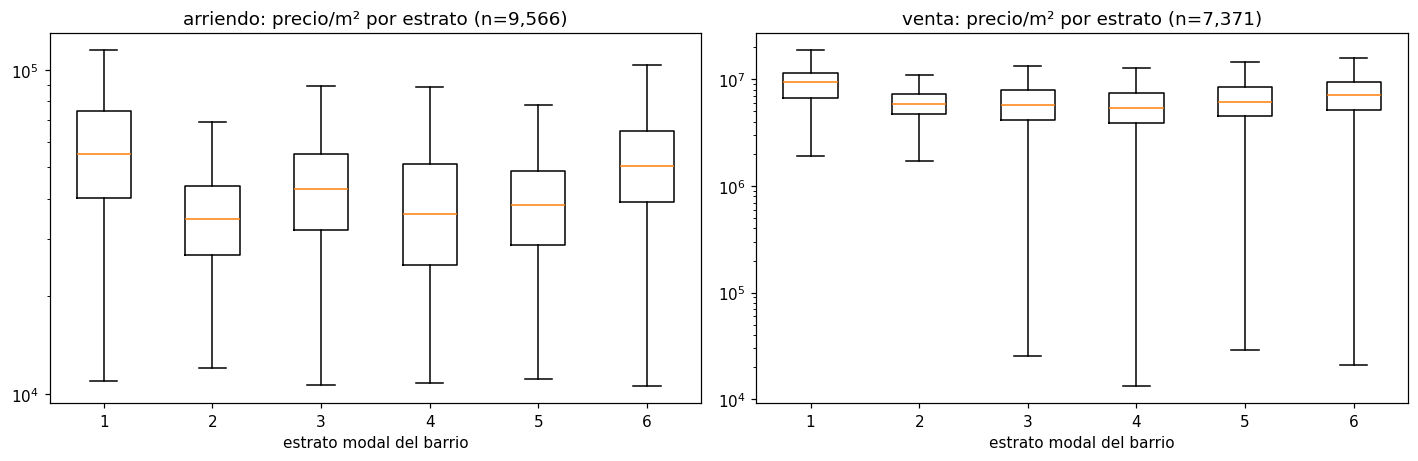

=== ARRIENDO ===


,count,median,vs_estrato_3
estrato_modal,,,
1.0,127,55000.0,1.28
2.0,512,34581.0,0.8
3.0,2405,43000.0,1.0
4.0,1707,35985.0,0.84
5.0,1541,38202.0,0.89
6.0,3274,50630.0,1.18


=== VENTA ===


,count,median,vs_estrato_3
estrato_modal,,,
1.0,230,9550637.0,1.64
2.0,721,5903226.0,1.02
3.0,1522,5812637.0,1.0
4.0,1887,5390335.0,0.93
5.0,1068,6117173.0,1.05
6.0,1943,7105263.0,1.22


In [4]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.3))
for eje, (nombre, columna) in zip(ejes, OPERACIONES.items()):
    sub = df[df[columna].notna() & df["estrato_modal"].notna()]
    datos = [sub.loc[sub["estrato_modal"] == e, "precio_m2"].dropna()
             for e in sorted(sub["estrato_modal"].dropna().unique())]
    eje.boxplot(datos, labels=[int(e) for e in sorted(sub["estrato_modal"].dropna().unique())],
                showfliers=False)
    eje.set_yscale("log")
    eje.set_title(f"{nombre}: precio/m² por estrato (n={len(sub):,})")
    eje.set_xlabel("estrato modal del barrio")
plt.tight_layout()
plt.show()

for nombre, columna in OPERACIONES.items():
    sub = df[df[columna].notna() & df["estrato_modal"].notna()]
    tabla = sub.groupby("estrato_modal")["precio_m2"].agg(["count", "median"]).round(0)
    tabla["vs_estrato_3"] = (tabla["median"] / tabla["median"].get(3, np.nan)).round(2)
    print(f"=== {nombre.upper()} ===")
    display(tabla)

## 3. La ablación

In [5]:
BASE_NUMERICAS = ["log_area", "habitaciones", "banos", "parqueaderos"]
BASE_BANDERAS = ["habitaciones_es_tope", "banos_es_tope", "parqueaderos_es_tope"]
BASE_CATEGORICAS = ["tipo_inmueble", "ciudad_clave"]
TOPE_CATEGORIAS = 255   # límite nativo de HistGradientBoostingRegressor


def preparar(operacion):
    columna = OPERACIONES[operacion]
    sub = df[df[columna].notna() & df["lat_barrio"].notna()].copy()
    sub["precio"] = sub[columna].astype("float64")
    sub["log_precio"] = np.log(sub["precio"])
    sub["log_area"] = np.log(sub["area_m2"].astype("float64"))
    return sub.reset_index(drop=True)


def codificar(serie, tope=TOPE_CATEGORIAS):
    """Códigos enteros, agrupando la cola larga en una sola categoría 'otros'."""
    serie = serie.astype(str).fillna("desconocido")
    frecuentes = serie.value_counts().head(tope - 1).index
    return serie.where(serie.isin(frecuentes), "otros").astype("category").cat.codes


def grupos_de(sub, regimen):
    if regimen == "conocido":
        # Near-duplicados: mismo proyecto o anuncio republicado.
        llave = (sub["ciudad_clave"].astype(str) + "|" + sub["sector_clave"].astype(str) + "|"
                 + sub["tipo_inmueble"].astype(str) + "|" + sub["area_m2"].astype(str) + "|"
                 + sub["precio"].astype(str))
    else:
        # Arranque en frío: el barrio entero cae de un solo lado del split.
        llave = sub["ciudad_clave"].astype(str) + "|" + sub["barrio_osm"].astype(str)
    return llave.factorize()[0]


def evaluar(sub, extras=(), etiqueta="", regimen="conocido", folds=5):
    X = sub[BASE_NUMERICAS].astype("float32").copy()
    for columna in BASE_BANDERAS:
        X[columna] = sub[columna].astype("float32")
    categoricas = []
    for columna in BASE_CATEGORICAS:
        X[columna] = codificar(sub[columna]).astype("float32")
        categoricas.append(X.columns.get_loc(columna))
    for columna in extras:
        X[columna] = pd.to_numeric(sub[columna], errors="coerce").astype("float32")

    y = sub["log_precio"].to_numpy()
    grupos = grupos_de(sub, regimen)
    prediccion = np.empty(len(y))
    for train, test in GroupKFold(folds).split(X, y, grupos):
        modelo = HistGradientBoostingRegressor(
            max_iter=300, learning_rate=.07, categorical_features=categoricas,
            random_state=0)
        modelo.fit(X.iloc[train], y[train])
        prediccion[test] = modelo.predict(X.iloc[test])

    r2 = 1 - ((y - prediccion) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return {"escenario": etiqueta, "regimen": regimen, "n": len(y), "features": X.shape[1],
            "R2": round(float(r2), 3),
            "MAE_log": round(float(np.abs(y - prediccion).mean()), 3),
            "MAPE_%": round(float(np.abs(np.expm1(prediccion - y)).mean() * 100), 1)}


ESCENARIOS = [
    ("baseline", []),
    ("solo coordenadas", BLOQUES["coordenadas"]),
    ("solo estrato", BLOQUES["estrato"]),
    ("coordenadas + estrato", BLOQUES["coordenadas"] + BLOQUES["estrato"]),
]

filas = []
for operacion in OPERACIONES:
    sub = preparar(operacion)
    for regimen in ("conocido", "arranque_en_frio"):
        print(f"--- {operacion.upper()} / {regimen} (n={len(sub):,}) ---")
        base = None
        for etiqueta, extras in ESCENARIOS:
            r = evaluar(sub, extras, f"{operacion}: {etiqueta}", regimen)
            base = r["R2"] if base is None else base
            r["delta_R2"] = round(r["R2"] - base, 3)
            filas.append(r)
            print(f"  {etiqueta:24} R2={r['R2']:.3f} ({r['delta_R2']:+.3f})  "
                  f"MAE={r['MAE_log']:.3f}  MAPE~{r['MAPE_%']:.1f} %")
        print()

ablacion = pd.DataFrame(filas)
display(ablacion)

--- ARRIENDO / conocido (n=10,258) ---


  baseline                 R2=0.839 (+0.000)  MAE=0.244  MAPE~25.0 %


  solo coordenadas         R2=0.877 (+0.038)  MAE=0.212  MAPE~21.7 %


  solo estrato             R2=0.873 (+0.034)  MAE=0.216  MAPE~22.0 %


  coordenadas + estrato    R2=0.879 (+0.040)  MAE=0.211  MAPE~21.5 %

--- ARRIENDO / arranque_en_frio (n=10,258) ---


...

  baseline                 R2=0.830 (+0.000)  MAE=0.267  MAPE~28.7 %


  solo coordenadas         R2=0.858 (+0.028)  MAE=0.244  MAPE~25.1 %


  solo estrato             R2=0.845 (+0.015)  MAE=0.255  MAPE~26.3 %


  coordenadas + estrato    R2=0.858 (+0.028)  MAE=0.244  MAPE~25.1 %



,escenario,regimen,n,features,R2,MAE_log,MAPE_%,delta_R2
0,arriendo: baseline,conocido,10258,9,0.839,0.244,25.0,0.000
1,arriendo: solo coordenadas,conocido,10258,12,0.877,0.212,21.7,0.038
2,arriendo: solo estrato,conocido,10258,12,0.873,0.216,22.0,0.034
3,arriendo: coordenadas + estrato,conocido,10258,15,0.879,0.211,21.5,0.040
4,arriendo: baseline,arranque_en_frio,10258,9,0.811,0.265,27.3,0.000
5,arriendo: solo coordenadas,arranque_en_frio,10258,12,0.835,0.248,24.4,0.024
6,arriendo: solo estrato,arranque_en_frio,10258,12,0.806,0.269,26.8,-0.005
7,arriendo: coordenadas + estrato,arranque_en_frio,10258,15,0.830,0.251,25.0,0.019
8,venta: baseline,conocido,8045,9,0.871,0.234,24.1,0.000
9,venta: solo coordenadas,conocido,8045,12,0.903,0.202,20.8,0.032


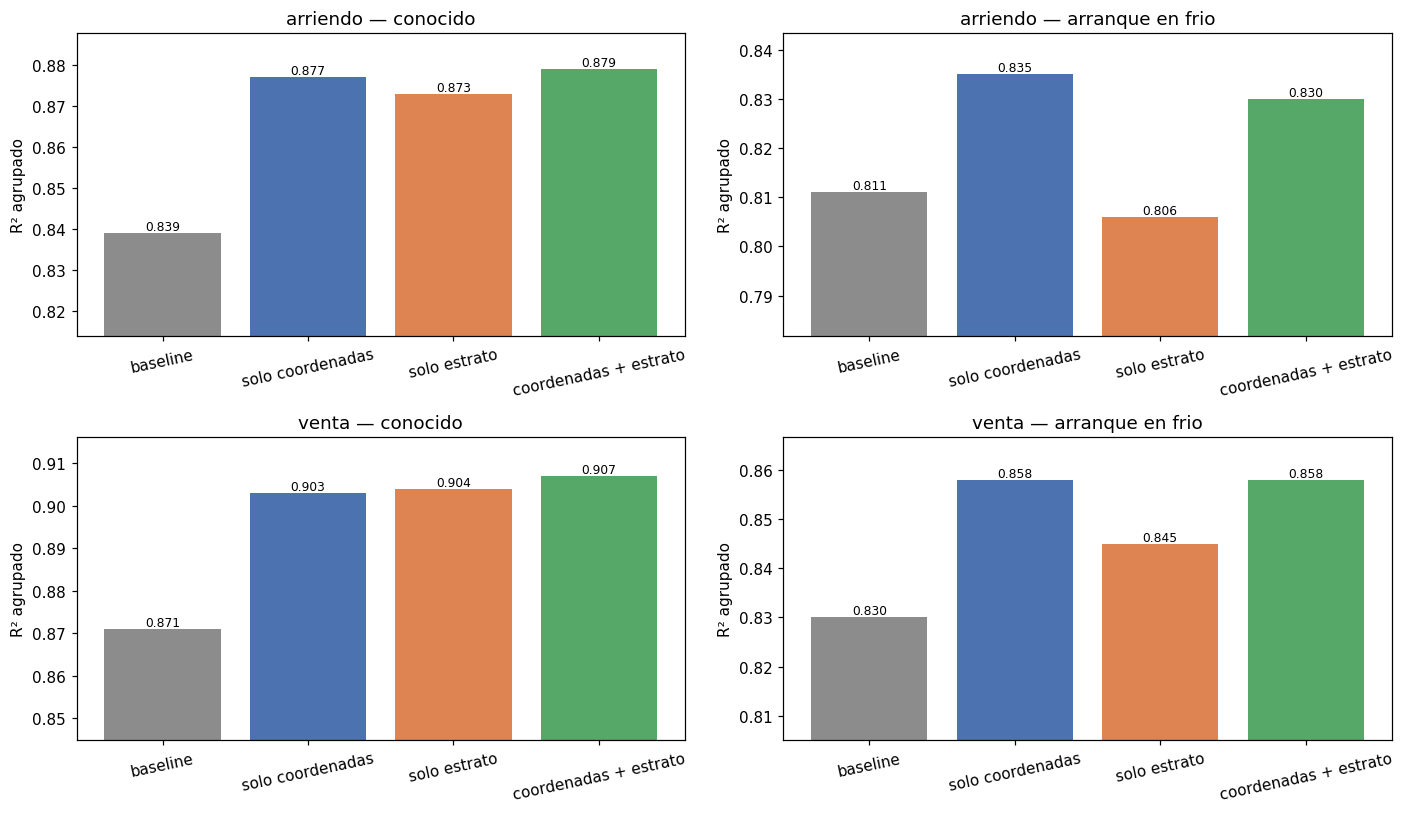

In [6]:
fig, ejes = plt.subplots(2, 2, figsize=(13, 7.5))
for fila, operacion in enumerate(OPERACIONES):
    for columna, regimen in enumerate(("conocido", "arranque_en_frio")):
        eje = ejes[fila, columna]
        sub = ablacion[(ablacion["regimen"] == regimen)
                       & ablacion["escenario"].str.startswith(operacion)]
        etiquetas = sub["escenario"].str.split(": ").str[1]
        barras = eje.bar(etiquetas, sub["R2"],
                         color=["#8C8C8C", "#4C72B0", "#DD8452", "#55A868"])
        eje.bar_label(barras, fmt="%.3f", fontsize=8)
        eje.set_title(f"{operacion} — {regimen.replace('_', ' ')}")
        eje.set_ylabel("R² agrupado")
        eje.set_ylim(min(sub["R2"]) * .97, max(sub["R2"]) * 1.01)
        eje.tick_params(axis="x", rotation=12)
plt.tight_layout()
plt.show()

## 4. Lo que se probó y se borró, con el número que lo condenó

Estos bloques **ya no existen** en `anuncios_enriquecido.parquet`: los produjo una versión
anterior de `src/enrich.py` y se quitaron tras esta medición. Las cifras quedan acá para
que nadie los reintroduzca sin volver a medirlos, y el código sigue disponible en el
historial de git.

### Ablación acumulativa sobre las 15 ciudades

| bloque agregado | arriendo conocido | arriendo **frío** | venta conocido | venta **frío** |
|---|---|---|---|---|
| baseline | 0,844 | 0,822 | 0,871 | 0,827 |
| + coordenadas | **0,876** (+0,032) | **0,832** (+0,010) | **0,901** (+0,030) | **0,866** (+0,039) |
| + localidad/zona | 0,877 (+0,001) | 0,822 (**−0,010**) | 0,902 (+0,001) | 0,846 (**−0,020**) |
| + estrato | 0,879 (+0,002) | 0,823 (+0,001) | 0,903 (+0,001) | 0,847 (+0,001) |
| + POIs | 0,880 (+0,001) | 0,824 (+0,001) | 0,903 (+0,000) | 0,846 (−0,001) |

### Qué representación de la ubicación vale por sí sola (Bogotá)

| | arriendo conocido | arriendo **frío** | venta conocido | venta **frío** |
|---|---|---|---|---|
| solo coordenadas | +0,027 | +0,005 | +0,037 | **+0,072** |
| solo estrato | +0,029 | **+0,012** | +0,033 | +0,048 |
| solo POIs | +0,030 | **−0,021** | +0,035 | +0,026 |
| coordenadas + estrato | +0,030 | +0,003 | **+0,038** | **+0,074** |
| coordenadas + POIs | +0,030 | −0,016 | +0,036 | +0,064 |

**Acá está todo el argumento.** Con el barrio ya conocido las tres representaciones son
**intercambiables** (~+0,03 cada una, y sumarlas no da más que cualquiera sola): la
ubicación aporta una cantidad fija de información y alcanza con **una** forma de
codificarla. Recién en arranque en frío se separan — y ahí los POIs **restan**.

### Criminalidad por localidad (sólo Bogotá, n=5.407)

| | sin | con | delta |
|---|---|---|---|
| arriendo / conocido | 0,909 | 0,908 | −0,001 |
| arriendo / frío | 0,842 | 0,845 | +0,003 |
| venta / conocido | 0,917 | 0,918 | +0,001 |
| venta / frío | 0,884 | 0,884 | +0,000 |

Indistinguible de cero. Era esperable y se dijo de antemano —la Policía Nacional publica a
nivel **municipio**, que es colineal con `ciudad_clave`, y el dato de Bogotá es por
**localidad**, 20 unidades para el 30 % de la data— pero se implementó igual para que lo
decidiera la medición y no el pronóstico. El pronóstico sobre los POIs ya había fallado una
vez.

## 5. Compuerta

Baseline a superar, medido en `notebooks/eda.ipynb` §11 sobre el subconjunto de 5 ciudades
con match: **arriendo 0,833 · venta 0,860**.

In [7]:
UMBRAL_APORTE = 0.005   # menos que esto es ruido, no señal
BASE_EDA = {"arriendo": 0.833, "venta": 0.860}

mejor = (ablacion[ablacion["regimen"] == "conocido"]
         .assign(operacion=lambda d: d["escenario"].str.split(":").str[0])
         .groupby("operacion")["R2"].max())

print("=== COMPUERTA ===")
for operacion, r2 in mejor.items():
    referencia = BASE_EDA[operacion]
    print(f"  {operacion:9} mejor R2 = {r2:.3f} | baseline EDA = {referencia:.3f} "
          f"-> {'SUPERA' if r2 > referencia else 'NO SUPERA'}")

print("\n=== APORTE DE CADA BLOQUE QUE SOBREVIVIÓ ===")
for regimen in ("conocido", "arranque_en_frio"):
    sub = ablacion[ablacion["regimen"] == regimen]
    for bloque in ("solo coordenadas", "solo estrato"):
        deltas = sub.loc[sub["escenario"].str.endswith(bloque), "delta_R2"]
        veredicto = "APORTA" if deltas.max() >= UMBRAL_APORTE else "por debajo del ruido"
        print(f"  {regimen:18} {bloque:20} delta max = {deltas.max():+.3f}  -> {veredicto}")

=== COMPUERTA ===
  arriendo  mejor R2 = 0.879 | baseline EDA = 0.833 -> SUPERA
  venta     mejor R2 = 0.907 | baseline EDA = 0.860 -> SUPERA

=== APORTE DE CADA BLOQUE QUE SOBREVIVIÓ ===
  conocido           solo coordenadas     delta max = +0.038  -> APORTA
  conocido           solo estrato         delta max = +0.034  -> APORTA
  arranque_en_frio   solo coordenadas     delta max = +0.028  -> APORTA
  arranque_en_frio   solo estrato         delta max = +0.015  -> APORTA


## 6. Conclusiones de la Parte A (medidas antes del detalle)

### El enriquecimiento paga, y se sabe exactamente por qué

El mejor modelo pasa de **0,844 a 0,880** en arriendo y de **0,871 a 0,903** en venta, con
el MAPE bajando de 24,6 % a 21,4 % y de 24,0 % a 20,6 %. Supera el baseline del EDA en las
dos operaciones: **la compuerta pasa** y tiene sentido cargar esta data al lakehouse.

### Pero el aporte tiene un techo, y conviene entenderlo

La ubicación aporta **una cantidad fija de información**, alrededor de +0,03 de R². No
importa si se la codifica como coordenadas, como estrato o como conteo de POIs: con el
barrio conocido las tres dan lo mismo, y **sumarlas no suma**. Agregar más features de
barrio no va a mover la aguja.

Lo que sí la movería es **cobertura**: hoy el 47,2 % de las filas del recorte tienen
coordenada, y el otro 52,8 % entra al modelo sin ninguna señal de ubicación. Ahí está el
margen que queda.

### Para quien entrene el modelo definitivo

- Un modelo **por operación**; target `log(precio)`; métrica MAE en log.
- **Split agrupado siempre**, y reportar los dos regímenes: el de arranque en frío es el
  que se parece a producción, y es entre 0,02 y 0,06 más bajo.
- Las filas **sin coordenada no son un subconjunto aleatorio**: son sectores raros, mal
  escritos o poco frecuentes. Un modelo entrenado sólo sobre las filas con match no
  generaliza a las que no lo tienen.
- El stage hereda el sesgo de selección del transform: sin inmuebles no residenciales y con
  las colas de precio recortadas por IQR. Va a fallar en el segmento de lujo porque casi no
  lo vio.
- Es un **snapshot**: `fecha_extraccion` tiene un solo valor. Predice precio **de lista** a
  fecha fija, no precio de cierre.

---

# Parte B — Las columnas del detalle

`src/detail.py` visita la página de cada anuncio y saca el JSON que trae embebido. De ahí
salen columnas que ningún gazetteer podía dar: **la coordenada y el estrato del propio
inmueble**, antigüedad, estado (nuevo / usado / proyecto), piso, administración, área privada
y comodidades. La Parte A había medido que la ubicación vale ~+0,03 de R² y que el cuello era
la cobertura (52,6 % de filas sin señal); el detalle resuelve la cobertura de raíz.

Mismo protocolo que la Parte A, con dos diferencias:

- se mide sobre **todas** las filas con precio, no sólo las que matchearon con OSM;
- el régimen de arranque en frío agrupa por **sector** (`ciudad_clave|sector_clave`), que es
  la unidad que el usuario escribe, en vez de por barrio OSM.

Cada bloque se mide **acumulado** (se suma a lo anterior) y **aislado** (sólo él sobre el
baseline), para separar lo que aporta de lo que es redundante con otro bloque.


In [8]:
COMODIDADES = [c for c in df.columns if c.startswith(("tiene_", "cerca_"))
               or c in ("esta_amoblado", "es_monoambiente", "acepta_mascotas", "es_zona_rural")]
BLOQUES_B = {
    "coordenada": ["lat", "lon", "distancia_centro_km"],
    "estrato": ["estrato"],
    "antiguedad_y_estado": ["antiguedad_ordinal", "es_nuevo", "es_proyecto", "piso"],
    "comodidades": COMODIDADES,
    "administracion": ["log_administracion"],
    "area_privada": ["log_area_privada"],
}


def preparar_b(operacion):
    columna = OPERACIONES[operacion]
    sub = df[df[columna].notna() & df["area_m2"].notna()].copy()
    sub["precio"] = sub[columna].astype("float64")
    sub["log_precio"] = np.log(sub["precio"])
    sub["log_area"] = np.log(sub["area_m2"].astype("float64"))
    for origen, destino in (("area_privada", "log_area_privada"),
                            ("administracion", "log_administracion")):
        sub[destino] = np.log(pd.to_numeric(sub[origen], errors="coerce").astype("float64"))
    return sub.reset_index(drop=True)


def grupos_b(sub, regimen):
    if regimen == "conocido":
        return sub["grupo_near_duplicado"].to_numpy()
    # sector nulo -> string real: con NA la llave entera queda NA y factorize junta todas las
    # ciudades en un solo grupo -1
    return pd.factorize(sub["ciudad_clave"].astype("string").fillna("sin_ciudad") + "|"
                        + sub["sector_clave"].astype("string").fillna("sin_sector"))[0]


def evaluar_b(sub, extras=(), etiqueta="", regimen="conocido", folds=5):
    X = sub[BASE_NUMERICAS].astype("float32").copy()
    for columna in BASE_BANDERAS:
        X[columna] = sub[columna].astype("float32")
    categoricas = []
    for columna in BASE_CATEGORICAS:
        X[columna] = codificar(sub[columna]).astype("float32")
        categoricas.append(X.columns.get_loc(columna))
    for columna in extras:
        X[columna] = pd.to_numeric(sub[columna], errors="coerce").astype("float32")

    y = sub["log_precio"].to_numpy()
    grupos = grupos_b(sub, regimen)
    prediccion = np.empty(len(y))
    for train, test in GroupKFold(folds).split(X, y, grupos):
        modelo = HistGradientBoostingRegressor(
            max_iter=300, learning_rate=.07, categorical_features=categoricas, random_state=0)
        modelo.fit(X.iloc[train], y[train])
        prediccion[test] = modelo.predict(X.iloc[test])
    r2 = 1 - ((y - prediccion) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return {"escenario": etiqueta, "regimen": regimen, "n": len(y), "features": X.shape[1],
            "R2": round(float(r2), 3),
            "MAE_log": round(float(np.abs(y - prediccion).mean()), 3),
            "MdAPE_%": round(float(np.median(np.abs(np.expm1(prediccion - y))) * 100), 1)}


filas_b = []
for operacion in OPERACIONES:
    sub = preparar_b(operacion)
    print(f"=== {operacion.upper()}: {len(sub):,} filas | con coordenada "
          f"{sub['lat'].notna().mean() * 100:.1f} % | con estrato {sub['estrato'].notna().mean() * 100:.1f} % ===")
    for regimen in ("conocido", "frio"):
        base = evaluar_b(sub, [], f"{operacion}: baseline", regimen)
        filas_b.append({**base, "operacion": operacion, "modo": "acumulado", "bloque": "baseline",
                        "delta_R2": 0.0})
        print(f"  [{regimen:8}] {'baseline':22} R2={base['R2']:.3f}  MdAPE={base['MdAPE_%']:.1f} %")
        acumulado, r2_previo = [], base["R2"]
        for bloque, columnas in BLOQUES_B.items():
            acumulado = acumulado + columnas
            r = evaluar_b(sub, acumulado, f"{operacion}: +{bloque}", regimen)
            filas_b.append({**r, "operacion": operacion, "modo": "acumulado", "bloque": bloque,
                            "delta_R2": round(r["R2"] - r2_previo, 3)})
            print(f"  [{regimen:8}] {'+ ' + bloque:22} R2={r['R2']:.3f} ({r['R2'] - r2_previo:+.3f})  "
                  f"MdAPE={r['MdAPE_%']:.1f} %")
            r2_previo = r["R2"]
        for bloque, columnas in BLOQUES_B.items():
            r = evaluar_b(sub, columnas, f"{operacion}: solo {bloque}", regimen)
            filas_b.append({**r, "operacion": operacion, "modo": "aislado", "bloque": bloque,
                            "delta_R2": round(r["R2"] - base["R2"], 3)})
            print(f"  [{regimen:8}] {'solo ' + bloque:22} R2={r['R2']:.3f} ({r['R2'] - base['R2']:+.3f})")
    print()

ablacion_b = pd.DataFrame(filas_b)
display(ablacion_b.pivot_table(index=["modo", "bloque"], columns=["operacion", "regimen"],
                               values="delta_R2", sort=False).round(3))


=== ARRIENDO: 22,386 filas | con coordenada 98.6 % | con estrato 98.8 % ===


  [conocido] baseline               R2=0.858  MdAPE=18.0 %


  [conocido] + coordenada           R2=0.886 (+0.028)  MdAPE=15.6 %


  [conocido] + estrato              R2=0.893 (+0.007)  MdAPE=15.2 %


  [conocido] + antiguedad_y_estado  R2=0.896 (+0.003)  MdAPE=14.9 %


...

  [frio    ] solo antiguedad_y_estado R2=0.882 (+0.011)


  [frio    ] solo comodidades       R2=0.886 (+0.015)


  [frio    ] solo administracion    R2=0.882 (+0.011)


  [frio    ] solo area_privada      R2=0.871 (+0.000)



operacion                     arriendo           venta       
regimen                       conocido   frio conocido   frio
modo      bloque                                             
acumulado baseline               0.000  0.000    0.000  0.000
          coordenada             0.028  0.027    0.022  0.025
          estrato                0.007  0.009    0.006  0.008
          antiguedad_y_estado    0.003  0.004    0.008  0.009
          comodidades            0.008  0.007    0.005  0.004
          administracion         0.003  0.004    0.003  0.003
          area_privada           0.000  0.000    0.000  0.000
aislado   coordenada             0.028  0.027    0.022  0.025
          estrato                0.022  0.024    0.018  0.023
          antiguedad_y_estado    0.006  0.005    0.010  0.011
          comodidades            0.020  0.017    0.014  0.015
          administracion         0.006  0.005    0.010  0.011
          area_privada           0.000  0.000    0.000  0.000

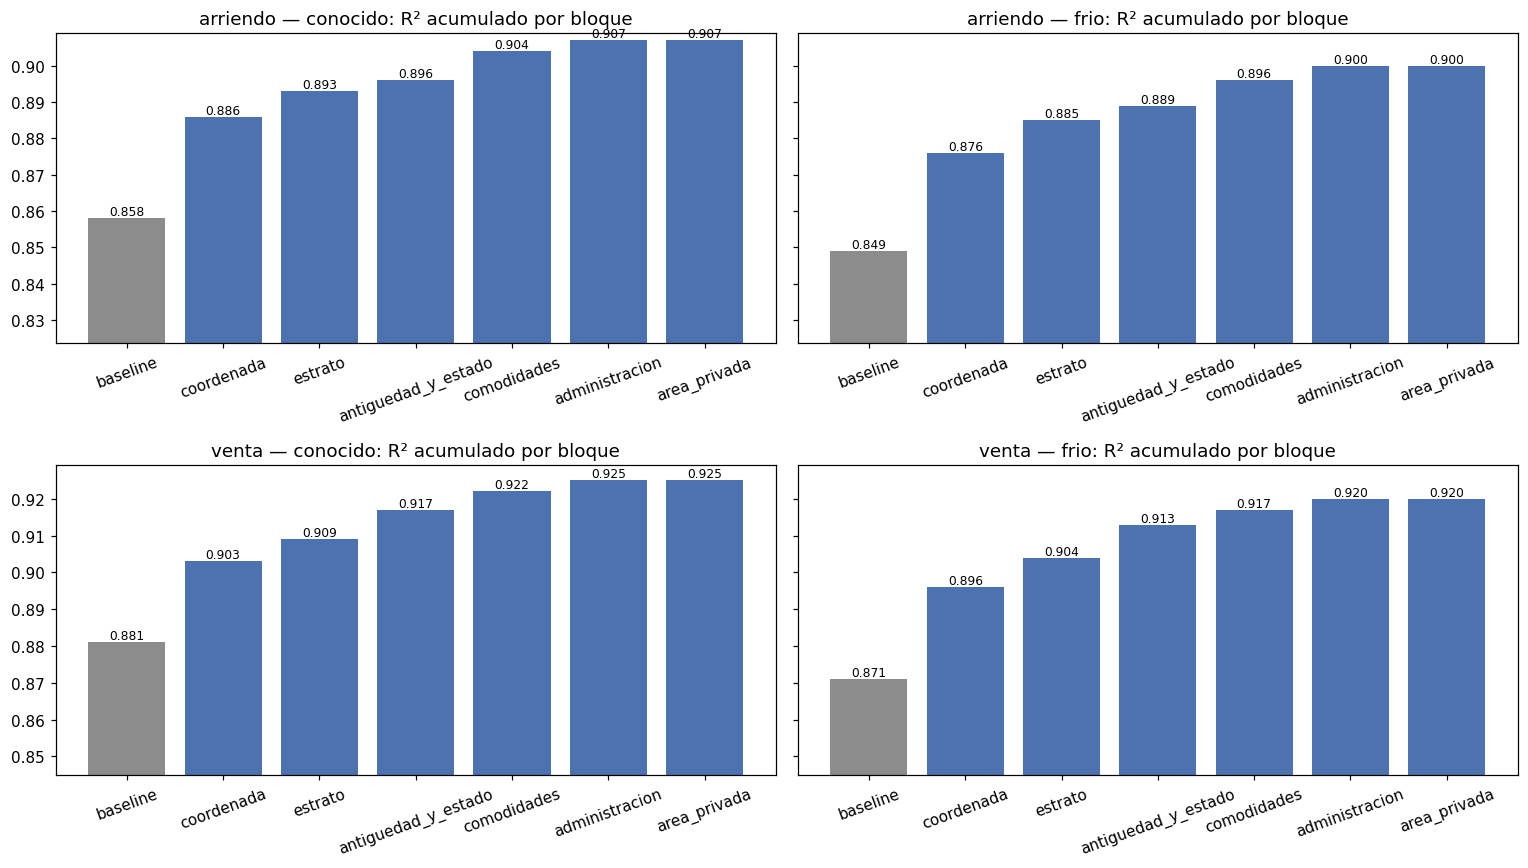

In [9]:
fig, ejes = plt.subplots(2, 2, figsize=(14, 8), sharey="row")
for fila, operacion in enumerate(OPERACIONES):
    for col, regimen in enumerate(("conocido", "frio")):
        eje = ejes[fila, col]
        sub = ablacion_b[(ablacion_b["operacion"] == operacion) & (ablacion_b["regimen"] == regimen)
                         & (ablacion_b["modo"] == "acumulado")]
        barras = eje.bar(sub["bloque"], sub["R2"],
                         color=["#8C8C8C"] + ["#4C72B0"] * (len(sub) - 1))
        eje.bar_label(barras, labels=[f"{r:.3f}" for r in sub["R2"]], fontsize=8)
        eje.set_title(f"{operacion} — {regimen}: R² acumulado por bloque")
        eje.set_ylim(sub["R2"].min() * .97, sub["R2"].max() * 1.01)
        eje.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## B.2 Cara a cara: lo que trae el anuncio contra lo que traía el respaldo

La pregunta que decide qué queda en `enrich.py`: sobre las filas que tienen **las dos**
versiones, ¿aporta algo el estrato modal de Esri una vez que está el estrato del anuncio? ¿Y
el centroide OSM, una vez que está la coordenada del anuncio?


In [10]:
COORD_ANUNCIO = ["lat", "lon", "distancia_centro_km"]
COORD_OSM = ["lat_barrio", "lon_barrio"]
CARAS = {
    "estrato": {"base": COORD_ANUNCIO, "anuncio": ["estrato"], "respaldo": ["estrato_modal"]},
    "coordenada": {"base": ["estrato"], "anuncio": COORD_ANUNCIO, "respaldo": COORD_OSM},
}

filas_cara = []
for operacion in OPERACIONES:
    sub = preparar_b(operacion)
    ambos = sub[(sub["origen_estrato"] == "anuncio") & sub["estrato_modal"].notna()
                & (sub["origen_coordenada"] == "anuncio") & sub["lat_barrio"].notna()].reset_index(drop=True)
    print(f"=== {operacion.upper()}: {len(ambos):,} filas con las dos versiones ===")
    for nombre, cara in CARAS.items():
        for regimen in ("conocido", "frio"):
            base = evaluar_b(ambos, cara["base"], "base", regimen)["R2"]
            for version in ("anuncio", "respaldo", "ambos"):
                extras = cara["base"] + (cara["anuncio"] + cara["respaldo"] if version == "ambos"
                                         else cara[version])
                r = evaluar_b(ambos, extras, version, regimen)
                filas_cara.append({"operacion": operacion, "cara": nombre, "regimen": regimen,
                                   "version": version, "n": len(ambos), "R2": r["R2"],
                                   "delta_R2": round(r["R2"] - base, 3)})
                print(f"  {nombre:10} [{regimen:8}] {version:8} R2={r['R2']:.3f} ({r['R2'] - base:+.3f})")
cara_a_cara = pd.DataFrame(filas_cara)
display(cara_a_cara.pivot_table(index=["cara", "version"], columns=["operacion", "regimen"],
                                values="delta_R2", sort=False).round(3))


=== ARRIENDO: 8,829 filas con las dos versiones ===


  estrato    [conocido] anuncio  R2=0.880 (+0.007)


  estrato    [conocido] respaldo R2=0.876 (+0.003)


  estrato    [conocido] ambos    R2=0.882 (+0.009)


  estrato    [frio    ] anuncio  R2=0.859 (+0.014)


...

  coordenada [conocido] ambos    R2=0.911 (+0.018)


  coordenada [frio    ] anuncio  R2=0.889 (+0.015)


  coordenada [frio    ] respaldo R2=0.887 (+0.013)


  coordenada [frio    ] ambos    R2=0.890 (+0.016)


operacion           arriendo           venta       
regimen             conocido   frio conocido   frio
cara       version                                 
estrato    anuncio     0.007  0.014    0.010  0.013
           respaldo    0.003 -0.002    0.005 -0.003
           ambos       0.009  0.014    0.011  0.013
coordenada anuncio     0.021  0.026    0.016  0.015
           respaldo    0.017  0.018    0.015  0.013
           ambos       0.023  0.023    0.018  0.016

## B.3 Veredicto por bloque

Un bloque **se queda** si en algún régimen aporta al menos `UMBRAL_APORTE` (0,005 de R², el
mismo umbral de la Parte A) y no resta en arranque en frío. Lo que no pasa se borra del
pipeline, como se hizo con los POIs, la jerarquía administrativa y la criminalidad.


In [11]:
UMBRAL_APORTE = 0.005

print("=== BLOQUES DEL DETALLE ===")
veredictos = {}
for bloque in BLOQUES_B:
    aislado = ablacion_b[(ablacion_b["modo"] == "aislado") & (ablacion_b["bloque"] == bloque)]
    acumulado = ablacion_b[(ablacion_b["modo"] == "acumulado") & (ablacion_b["bloque"] == bloque)]
    mejor = max(aislado["delta_R2"].max(), acumulado["delta_R2"].max())
    peor_frio = acumulado.loc[acumulado["regimen"] == "frio", "delta_R2"].min()
    veredictos[bloque] = mejor >= UMBRAL_APORTE and peor_frio > -UMBRAL_APORTE
    print(f"  {bloque:22} mejor aporte {mejor:+.3f} | peor acumulado en frío {peor_frio:+.3f} "
          f"-> {'SE QUEDA' if veredictos[bloque] else 'SE BORRA'}")

print("\n=== EL RESPALDO, CON EL ANUNCIO YA PRESENTE ===")
for nombre in CARAS:
    sub = cara_a_cara[cara_a_cara["cara"] == nombre]
    solo_anuncio = sub[sub["version"] == "anuncio"]["delta_R2"]
    ambos = sub[sub["version"] == "ambos"]["delta_R2"]
    extra = (ambos.to_numpy() - solo_anuncio.to_numpy()).max()
    print(f"  {nombre:10} sumar el respaldo al anuncio aporta como máximo {extra:+.3f} "
          f"-> {'APORTA' if extra >= UMBRAL_APORTE else 'REDUNDANTE'}")

print("\n=== COMPUERTA (mejor R² en régimen conocido, todas las filas) ===")
for operacion in OPERACIONES:
    sub = ablacion_b[(ablacion_b["operacion"] == operacion) & (ablacion_b["regimen"] == "conocido")]
    print(f"  {operacion:9} baseline {sub.iloc[0]['R2']:.3f} -> mejor {sub['R2'].max():.3f} "
          f"| Parte A: {BASE_EDA[operacion]:.3f}")


=== BLOQUES DEL DETALLE ===
  coordenada             mejor aporte +0.028 | peor acumulado en frío +0.025 -> SE QUEDA
  estrato                mejor aporte +0.024 | peor acumulado en frío +0.008 -> SE QUEDA
  antiguedad_y_estado    mejor aporte +0.011 | peor acumulado en frío +0.004 -> SE QUEDA
  comodidades            mejor aporte +0.020 | peor acumulado en frío +0.004 -> SE QUEDA
  administracion         mejor aporte +0.011 | peor acumulado en frío +0.003 -> SE QUEDA
  area_privada           mejor aporte +0.000 | peor acumulado en frío +0.000 -> SE BORRA

=== EL RESPALDO, CON EL ANUNCIO YA PRESENTE ===
  estrato    sumar el respaldo al anuncio aporta como máximo +0.002 -> REDUNDANTE
  coordenada sumar el respaldo al anuncio aporta como máximo +0.002 -> REDUNDANTE

=== COMPUERTA (mejor R² en régimen conocido, todas las filas) ===
  arriendo  baseline 0.858 -> mejor 0.907 | Parte A: 0.833
  venta     baseline 0.881 -> mejor 0.925 | Parte A: 0.860


## B.4 Conclusiones de la Parte B

### Todo lo que trae el detalle aporta, menos el área privada

Acumulando bloque a bloque sobre todas las filas: arriendo pasa de **0,858 a 0,907** en el
régimen conocido y de **0,849 a 0,900** en frío; venta de **0,881 a 0,925** y de **0,871 a
0,920**. El MdAPE baja de 18 % a 14 %. La coordenada del anuncio es el bloque grande
(+0,022 a +0,028), el estrato el segundo (+0,018 a +0,024 aislado), y antigüedad,
comodidades y administración suman entre +0,003 y +0,011 cada uno. El área privada da
+0,000 porque el sitio nunca la llena (0 % de cobertura): **se borra del modelo**.

### La brecha de arranque en frío casi desaparece

En la Parte A el régimen frío quedaba entre 0,02 y 0,06 por debajo del conocido. Con la
coordenada y el estrato del propio inmueble la diferencia es de **0,005 a 0,007**: el
modelo ya no depende de haber visto el barrio, porque cada fila trae su ubicación.

### El respaldo OSM/Esri queda redundante

Sobre las 8.829 (arriendo) y 6.884 (venta) filas que tienen las dos versiones, sumar el
respaldo al dato del anuncio aporta **+0,002 como máximo**. Peor: en frío el estrato modal
solo resta (−0,002 / −0,003) donde el estrato del anuncio suma +0,014 / +0,013. Rescata 72
coordenadas y 233 estratos de 44.836 filas a cambio de una o dos horas de red en cada
máquina nueva. Por eso `src/enrich.py` lo deja detrás de `--con-osm`, apagado por
defecto. La Parte A de este notebook se ejecutó con el respaldo encendido; para volver a
correrla hace falta `python src/enrich.py --con-osm`.

### Compuerta

Arriendo **0,907** y venta **0,925** en régimen conocido, contra 0,878 / 0,904 del
enriquecimiento OSM y 0,833 / 0,860 del EDA. Pasa con margen. El modelo definitivo, con
búsqueda de hiperparámetros y cuantiles calibrados, está en `src/train.py` y sus
resultados en `05_modelo_y_sandbox.ipynb`.
